Длительность,с
4496.0
None
Средняя длительность,с
0.3764074666666667

Медиана длительность,с
0.14800000000000013

Средняя частота,Гц
2.6206896551724137

Пульс
157.24137931034483

Количество кардиоциклов =76
(1000,)
Длительность=0.16
Отношение 0.03436196365292579
{'fQRS_ms': 26.880000000000003, 'RMS40_uV': 192.67490728933748, 'LAS40_ms': 0.0, 'QRSon': 274, 'QRSoff': 442, 'noise_std': 16.000198964443786}
(1000,)
Min freq: 4.963954056695992, Max freq: 5078.125
Min scale: 3.0, Max scale: 50782.0
(21, 1000)
(21,)
Средняя длительность,с
0.24400116788321172

Медиана длительность,с
0.1627200000000002

Средняя частота,Гц
4.0588235294117645

Пульс
243.52941176470588

Количество кардиоциклов =138
(1000,)
Длительность=0.16
Отношение 0.040347817460102804
(1000,)
Min freq: 4.963954056695992, Max freq: 5078.125
Min scale: 3.0, Max scale: 50782.0
(21, 1000)
(21,)
{'fQRS_ms': 40.800000000000004, 'RMS40_uV': 137.49592550321083, 'LAS40_ms': 0.32, 'QRSon': 249, 'QRSoff': 504, 'noise_std': 8.94209569854767

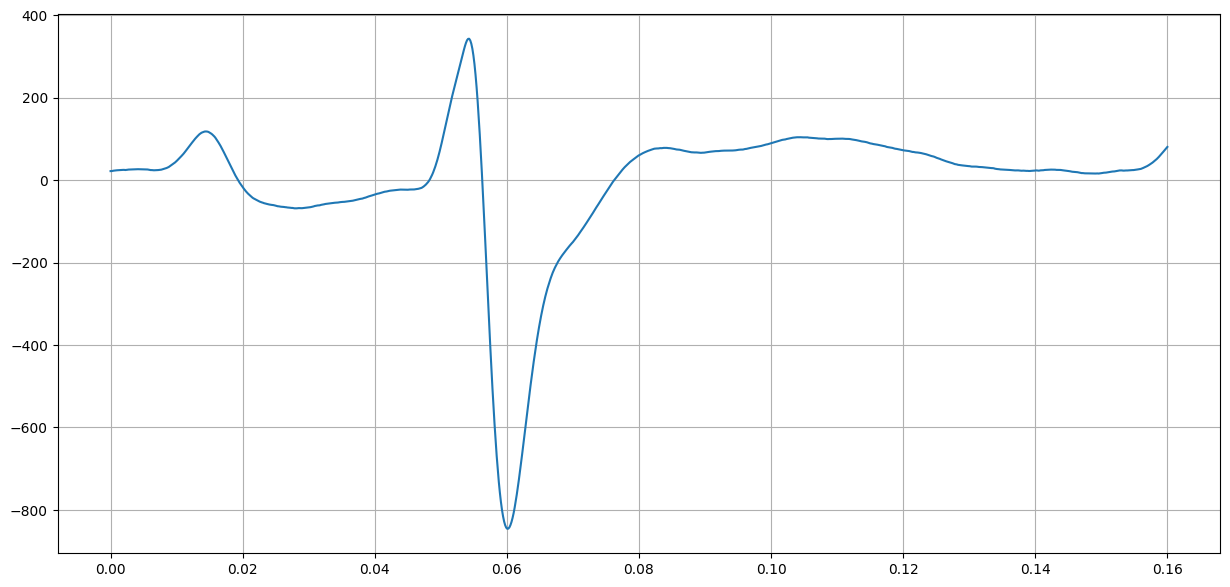

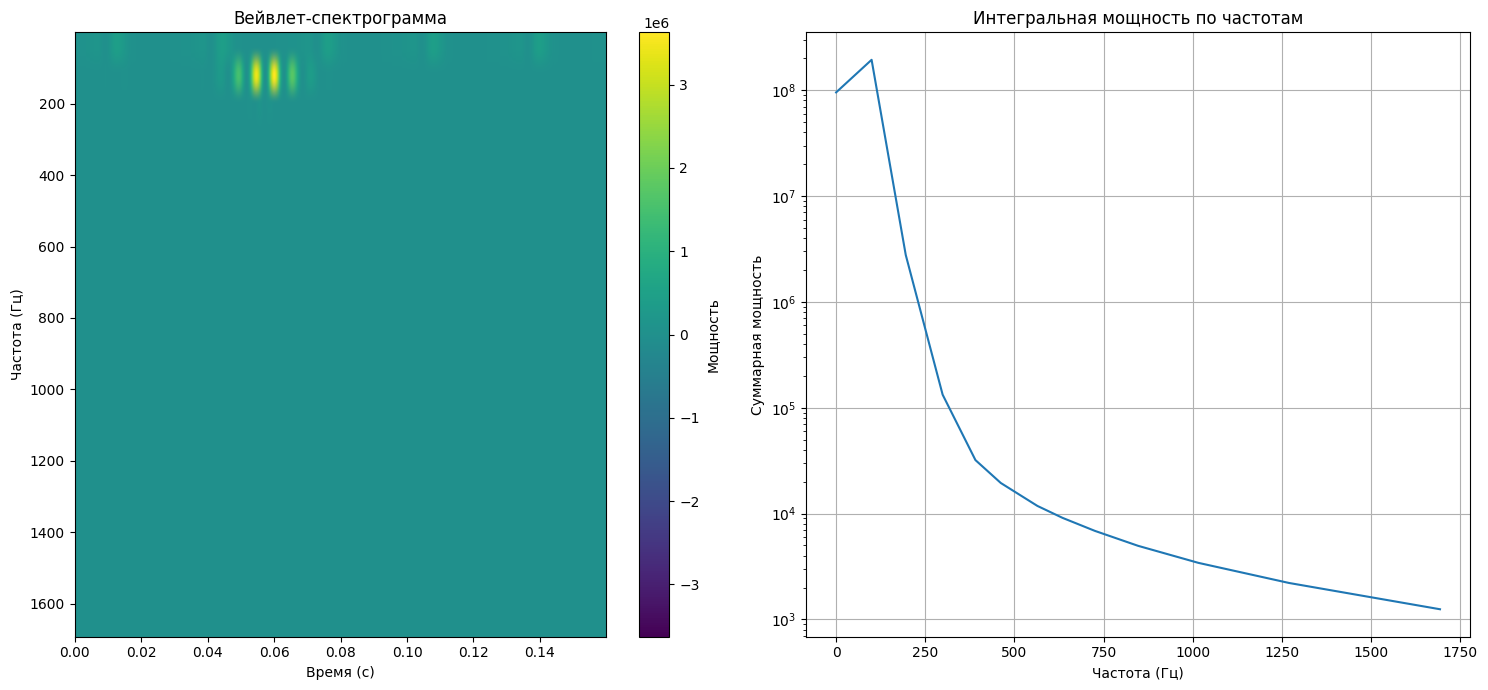

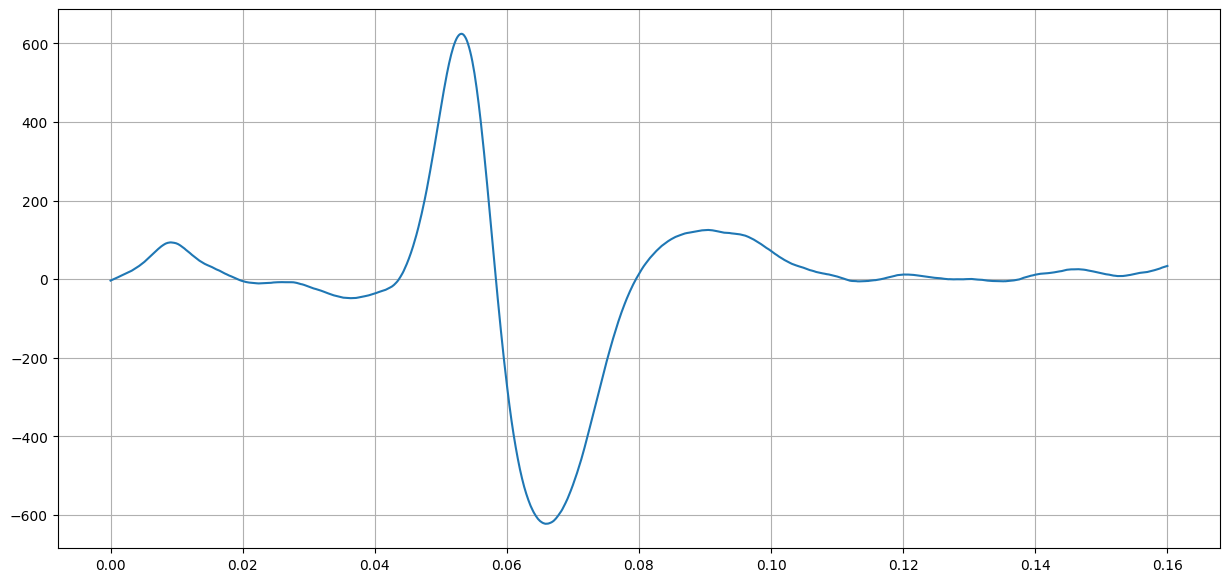

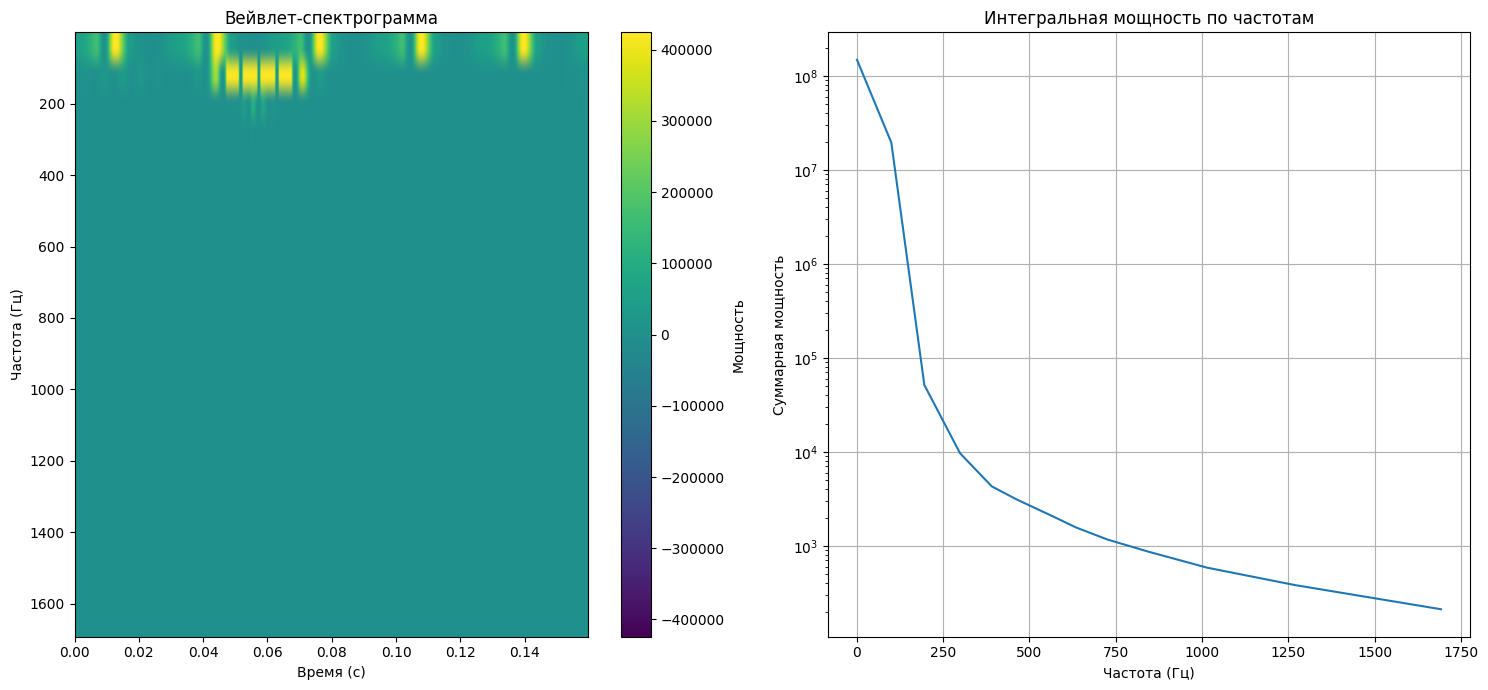

In [3]:
from  time_slice import time_slice
from read_edf import read_edf
from findpeaks import findpeaks
from scipy import signal
import matplotlib.pyplot as plt
import biosppy
import numpy as np
from signalavergedecg import signalavergedecg
from compute_late_potentials_from_avg import compute_late_potentials_from_avg
from waveletscaleaogram import waveletscaleaogram


def main():
    chanel_d,time,fs1,anot=read_edf("12_2_Not_filtered.edf","D:/ECG_IAI_RAS/RAT_NEW/12/2_rat/",[0, 1, 2, 3, 4, 5])
    sig1=chanel_d.get('II_LF           ')
    print('Длительность,с')
    print(len(sig1)/fs1)
    print(anot)
    stabilization_time=0
    ishemia_time=1688
    reperfusion_time=3600

    ynorm=time_slice(
        sig1 - np.mean(sig1),
        stabilization_time+5,
        stabilization_time+34,
        fs1
    )

    ypat=time_slice(
        sig1 - np.mean(sig1),
        ishemia_time,
        ishemia_time+34,
        fs1
    )
    rpeaks=findpeaks(ynorm,fs1)
    saecgnorm=signalavergedecg(ynorm,fs1,rpeaks)
    plt.figure(figsize=(15,7))
    plt.plot(np.linspace(0,len(saecgnorm)/fs1,len(saecgnorm)),saecgnorm)
    plt.grid(True)
    parnorm=compute_late_potentials_from_avg(saecgnorm,fs1)
    print(parnorm)

    Spnorm,frequenciesnorm,powernorm=waveletscaleaogram(saecgnorm,fs1)

    plt.figure(figsize=(15,7))
    plt.subplot(121)
    time_axis = np.arange(powernorm.shape[1]) / fs1  
    plt.imshow(powernorm, 
           extent=[time_axis[0], time_axis[-1], frequenciesnorm[-1], frequenciesnorm[0]], 
           cmap='viridis', 
           aspect='auto',
           vmax=abs(powernorm).max(), 
           vmin=-abs(powernorm).max())  
    plt.colorbar(label='Мощность')
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.title('Вейвлет-спектрограмма')
    plt.subplot(122)
    plt.semilogy(frequenciesnorm, Spnorm)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Суммарная мощность')
    plt.title('Интегральная мощность по частотам')
    plt.grid(True)
    plt.tight_layout()
        
  
    rpeaks=findpeaks(ypat,fs1)
    saecgpat=signalavergedecg(ypat,fs1,rpeaks)
    plt.figure(figsize=(15,7))
    plt.plot(np.linspace(0,len(saecgpat)/fs1,len(saecgpat)),saecgpat)
    plt.grid(True)

    Sppat,frequenciespat,powerpat=waveletscaleaogram(saecgpat,fs1)

    plt.figure(figsize=(15,7))
    plt.subplot(121)
    time_axis = np.arange(powerpat.shape[1]) / fs1  
    plt.imshow(powernorm, 
           extent=[time_axis[0], time_axis[-1], frequenciespat[-1], frequenciespat[0]], 
           cmap='viridis', 
           aspect='auto',
           vmax=abs(powerpat).max(), 
           vmin=-abs(powerpat).max())  
    plt.colorbar(label='Мощность')
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.title('Вейвлет-спектрограмма')
    plt.subplot(122)
    plt.semilogy(frequenciespat, Sppat)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Суммарная мощность')
    plt.title('Интегральная мощность по частотам')
    plt.grid(True)
    plt.tight_layout()

    parpat=compute_late_potentials_from_avg(saecgpat,fs1)
    
    print(parpat)


    
   
    plt.show()
    
    
    
    
if __name__ == "__main__":
    main()



    
    

